In [1]:
from superfv import HydroSolver, BC, ics, MUSCL_SlopeLimiter, RiemannSolver, HydroSolverOutput
import spd.initial_conditions as ic
from spd.sdfb_simulator import SPD_Simulator
import matplotlib as mpl
import matplotlib.pyplot as plt
from functools import partial
import os
import shutil

try:
    import cupy as cp
except ModuleNotFoundError:
    cp = None

mpl.rcParams["font.size"] = 15

In [2]:
if cp is None:
    print("cupy not available; running on CPU only")
else:
    for i in range(cp.cuda.runtime.getDeviceCount()):
        cp.cuda.runtime.setDevice(i)
        print([f"{round(x/1E9,2)}GB" for x in cp.cuda.runtime.memGetInfo()])

['41.96GB', '42.41GB']


In [3]:
base_directory = "/scratch/gpfs/jp7427/FVvsSD/rti/"

In [4]:
def run_superfv_sim(name, p, N, P0=1, **kwargs):
    path = base_directory + f"FV_{name}_{P0=}_{N=}_{p=}"

    try:
        out = HydroSolverOutput(path)
        print(f"Loaded output from '{path}'")
        return out
    except Exception as e:
        print(f"Failed to load output from '{path}' with: {e}")
        pass

    if os.path.exists(path):
        print(f"Removing bad output at '{path}'")
        shutil.rmtree(path)
    
    def gravity(idx, u, *, xp):
        gx = 0.0
        gy = 1.0
        out = xp.zeros_like(u)
        out[idx("mx")] = u[idx("rho")] * gx
        out[idx("my")] = u[idx("rho")] * gy
        out[idx("E")] = u[idx("mx")] * gx + u[idx("my")] * gy
        return out

    sim = HydroSolver(
        ic=partial(ics.rayleigh_taylor, gamma=5 / 3, P0=P0),
        gamma=5 / 3,
        rho_min=1e-10,
        P_min=1e-10,
        source=gravity,
        xlims=(0, 0.25),
        ylims=(0, 1),
        nx=N // 4,
        ny=N,
        bcy=(BC.REFLECTIVE, BC.REFLECTIVE),
        p=p,
        use_MOOD=True,
        use_NAD=True,
        use_SED=True,
        blend_troubles=False,
        MUSCL_limiter=MUSCL_SlopeLimiter.MONCEN,
        cupy=True,
        output_path=path,
        **kwargs,
    )
    sim.run(1.95)
    return sim

In [5]:
def run_spd_sim(name, p, N, P0=1, **kwargs):
    path = base_directory + f"SD_{name}_{P0=}_{N=}_{p=}"
    
    sim = SPD_Simulator(
        p=p,
        N=(N // 4, N),
        xlim=(0.0, 0.25),
        ylim=(0.0, 1.0),
        BC=(
            ("periodic", "periodic"),  # x
            ("reflective", "reflective"),  # y
        ),
        init_fct=ic.RTI(P0=1, gamma=5 / 3),
        cfl_coeff=0.4,
        use_cupy=True,
        time_integrator="rk3",
        fallback="MUSCL",
        slope_limiter="moncen",
        scheme="SDFB",
        potential=True,
        NAD="",
        PAD=True,
        SED=True,
        blending=False,
        riemann_solver_fv="hllc",  # MUSCL fallback flux
        folder=path,
        **kwargs,
    )

    try:
        sim.load_output()
        print(f"Loaded output from '{path}'")
        return sim
    except Exception as e:
        print(f"Failed to load output from '{path}' with: {e}")
        pass

    sim.perform_time_evolution(1.95)
    sim.output()
    return sim
        

In [6]:
def plot_both(fv_sim, sd_sim):
    fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, constrained_layout=True, figsize=(5, 6))

    for ax in axs:
        ax.set_aspect("equal")

    x_sd = sd_sim.regular_faces()[0]
    y_sd = sd_sim.regular_faces()[1]
    z_sd = sd_sim.transpose_to_fv(sd_sim.regular_mesh(sd_sim.dm.W_cv))[0]

    x_fv, y_fv, _ = fv_sim.mesh.faces
    z_fv = fv_sim.snapshot_history[-1].w[0, :, :, 0].T

    vmin = min(z_fv.min().item(), z_sd.min().item())
    vmax = max(z_fv.max().item(), z_sd.max().item())

    axs[0].set_title("FV4")
    axs[0].pcolormesh(cp.asnumpy(x_fv), cp.asnumpy(y_fv), z_fv, vmin=vmin, vmax=vmax)

    axs[1].set_title("SD4")
    m1 = axs[1].pcolormesh(x_sd, y_sd, z_sd, vmin=vmin, vmax=vmax)
    fig.colorbar(m1, ax=axs[1], pad=0.15)
    return fig, axs


def plot_fv(ax, sim):
    ax.set_aspect("equal")

    x_fv, y_fv, _ = sim.mesh.faces
    z_fv = sim.snapshot_history[-1].w[0, :, :, 0].T
    return ax.pcolormesh(cp.asnumpy(x_fv), cp.asnumpy(y_fv), z_fv)


def plot_sd(ax, sim):
    ax.set_aspect("equal")

    x_sd = sim.regular_faces()[0]
    y_sd = sim.regular_faces()[1]
    z_sd = sim.transpose_to_fv(sim.regular_mesh(sim.dm.W_cv))[0]
    return ax.pcolormesh(x_sd, y_sd, z_sd)

In [7]:
NDOF = 192
p = 3
N = NDOF // (p + 1)

In [8]:
s1 = run_superfv_sim("rtol=1e-1", p, NDOF, P0=1, rtol=1e-1)
s2 = run_superfv_sim("rtol=1e-3", p, NDOF, P0=1, rtol=1e-3)
s3 = run_superfv_sim("rtol=1e-5", p, NDOF, P0=1, rtol=1e-5)
s4 = run_superfv_sim("rtol=0", p, NDOF, P0=1, rtol=0)

Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_rtol=1e-1_P0=1_N=192_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_rtol=1e-3_P0=1_N=192_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_rtol=1e-5_P0=1_N=192_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_rtol=0_P0=1_N=192_p=3'


In [9]:
s5 = run_spd_sim("rtol=1e-1", p, N, P0=1, limiting_variables=[0, 1, 2, 4], tolerance=1e-1, riemann_solver_sd="hllc")
s6 = run_spd_sim("rtol=1e-3", p, N, P0=1, limiting_variables=[0, 1, 2, 4], tolerance=1e-3, riemann_solver_sd="hllc")
s7 = run_spd_sim("rtol=1e-5", p, N, P0=1, limiting_variables=[0, 1, 2, 4], tolerance=1e-5, riemann_solver_sd="hllc")
s8 = run_spd_sim("rtol=0", p, N, P0=1, limiting_variables=[0, 1, 2, 4], tolerance=0.0, riemann_solver_sd="hllc")

Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_rtol=1e-1_P0=1_N=48_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_rtol=1e-3_P0=1_N=48_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_rtol=1e-5_P0=1_N=48_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_rtol=0_P0=1_N=48_p=3'


-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_rtol=1e-1_P0=1_N=192_p=3/output_000001.pkl.
-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_rtol=1e-3_P0=1_N=192_p=3/output_000001.pkl.
-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_rtol=1e-5_P0=1_N=192_p=3/output_000001.pkl.
-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_rtol=0_P0=1_N=192_p=3/output_000001.pkl.


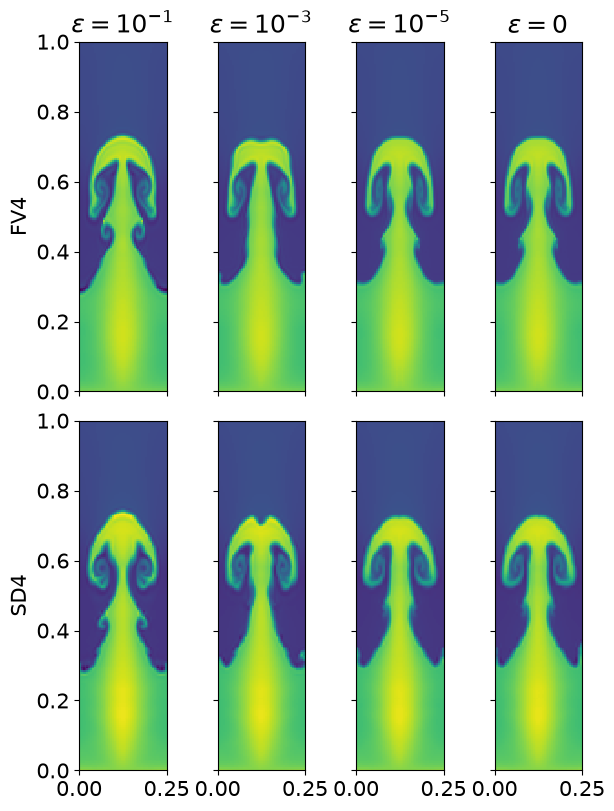

In [10]:
fig, axs = plt.subplots(2, 4, sharex=True, sharey=True, constrained_layout=True, figsize=(6, 8))
axs[0, 0].set_ylabel("FV4")
axs[1, 0].set_ylabel("SD4")
axs[0, 0].set_title(r"$\varepsilon=10^{-1}$")
axs[0, 1].set_title(r"$\varepsilon=10^{-3}$")
axs[0, 2].set_title(r"$\varepsilon=10^{-5}$")
axs[0, 3].set_title(r"$\varepsilon=0$")

meshes = []
for i, s in enumerate([s1, s2, s3, s4]):
    meshes.append(plot_fv(axs[0, i], s))
for i, s in enumerate([s5, s6, s7, s8]):
    meshes.append(plot_sd(axs[1, i], s))

vmin = min(m.get_array().min() for m in meshes)
vmax = max(m.get_array().max() for m in meshes)

for m in meshes:
    m.set_clim(vmin, vmax)

In [11]:
s1 = run_superfv_sim("LLF_rtol=1e-1", p, NDOF, P0=1, rtol=1e-1, riemann_solver=RiemannSolver.LLF, fallback_riemann_solver=RiemannSolver.HLLC)
s2 = run_superfv_sim("LLF_rtol=1e-3", p, NDOF, P0=1, rtol=1e-3, riemann_solver=RiemannSolver.LLF, fallback_riemann_solver=RiemannSolver.HLLC)
s3 = run_superfv_sim("LLF_rtol=1e-5", p, NDOF, P0=1, rtol=1e-5, riemann_solver=RiemannSolver.LLF, fallback_riemann_solver=RiemannSolver.HLLC)
s4 = run_superfv_sim("LLF_rtol=0", p, NDOF, P0=1, rtol=0, riemann_solver=RiemannSolver.LLF, fallback_riemann_solver=RiemannSolver.HLLC)

Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_LLF_rtol=1e-1_P0=1_N=192_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_LLF_rtol=1e-3_P0=1_N=192_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_LLF_rtol=1e-5_P0=1_N=192_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_LLF_rtol=0_P0=1_N=192_p=3'


In [12]:
s5 = run_spd_sim("LLF_rtol=1e-1", p, N, P0=1, limiting_variables=[0, 1, 2, 4], tolerance=1e-1, riemann_solver_sd="llf")
s6 = run_spd_sim("LLF_rtol=1e-3", p, N, P0=1, limiting_variables=[0, 1, 2, 4], tolerance=1e-3, riemann_solver_sd="llf")
s7 = run_spd_sim("LLF_rtol=1e-5", p, N, P0=1, limiting_variables=[0, 1, 2, 4], tolerance=1e-5, riemann_solver_sd="llf")
s8 = run_spd_sim("LLF_rtol=0", p, N, P0=1, limiting_variables=[0, 1, 2, 4], tolerance=0.0, riemann_solver_sd="llf")

Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_LLF_rtol=1e-1_P0=1_N=48_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_LLF_rtol=1e-3_P0=1_N=48_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_LLF_rtol=1e-5_P0=1_N=48_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_LLF_rtol=0_P0=1_N=48_p=3'


-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_LLF_rtol=1e-1_P0=1_N=192_p=3/output_000001.pkl.
-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_LLF_rtol=1e-3_P0=1_N=192_p=3/output_000001.pkl.
-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_LLF_rtol=1e-5_P0=1_N=192_p=3/output_000001.pkl.
-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_LLF_rtol=0_P0=1_N=192_p=3/output_000001.pkl.


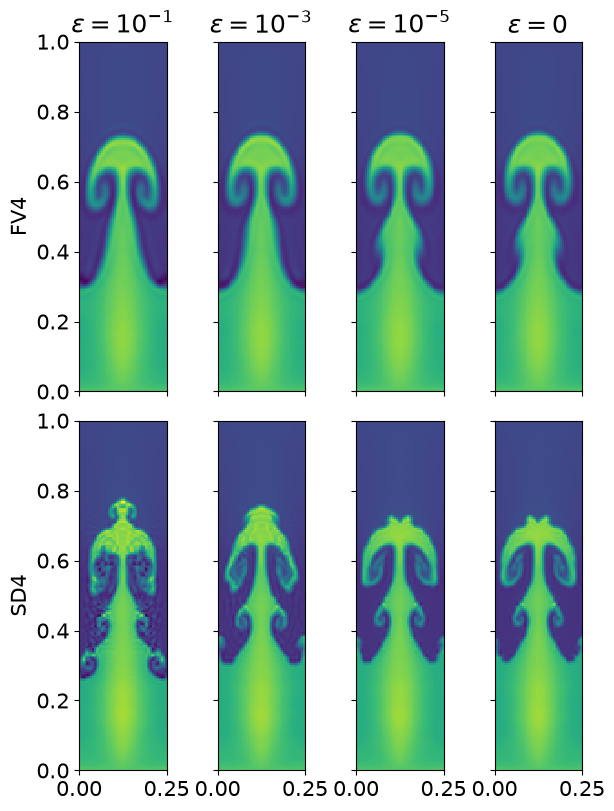

In [13]:
fig, axs = plt.subplots(2, 4, sharex=True, sharey=True, constrained_layout=True, figsize=(6, 8))
axs[0, 0].set_ylabel("FV4")
axs[1, 0].set_ylabel("SD4")
axs[0, 0].set_title(r"$\varepsilon=10^{-1}$")
axs[0, 1].set_title(r"$\varepsilon=10^{-3}$")
axs[0, 2].set_title(r"$\varepsilon=10^{-5}$")
axs[0, 3].set_title(r"$\varepsilon=0$")

meshes = []
for i, s in enumerate([s1, s2, s3, s4]):
    meshes.append(plot_fv(axs[0, i], s))
for i, s in enumerate([s5, s6, s7, s8]):
    meshes.append(plot_sd(axs[1, i], s))

vmin = min(m.get_array().min() for m in meshes)
vmax = max(m.get_array().max() for m in meshes)

for m in meshes:
    m.set_clim(vmin, vmax)

In [14]:
s1 = run_superfv_sim("2varNAD_rtol=1e-1", p, NDOF, P0=1, rtol=1e-1, omit_vars_from_NAD=["vx", "vy", "vz"])
s2 = run_superfv_sim("2varNAD_rtol=1e-3", p, NDOF, P0=1, rtol=1e-3, omit_vars_from_NAD=["vx", "vy", "vz"])
s3 = run_superfv_sim("2varNAD_rtol=1e-5", p, NDOF, P0=1, rtol=1e-5, omit_vars_from_NAD=["vx", "vy", "vz"])
s4 = run_superfv_sim("2varNAD_rtol=0", p, NDOF, P0=1, rtol=0, omit_vars_from_NAD=["vx", "vy", "vz"])

Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_2varNAD_rtol=1e-1_P0=1_N=192_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_2varNAD_rtol=1e-3_P0=1_N=192_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_2varNAD_rtol=1e-5_P0=1_N=192_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/FV_2varNAD_rtol=0_P0=1_N=192_p=3'


In [15]:
s5 = run_spd_sim("2varNAD_rtol=1e-1", p, N, P0=1, limiting_variables=[0, 4], tolerance=1e-1, riemann_solver_sd="hllc")
s6 = run_spd_sim("2varNAD_rtol=1e-3", p, N, P0=1, limiting_variables=[0, 4], tolerance=1e-3, riemann_solver_sd="hllc")
s7 = run_spd_sim("2varNAD_rtol=1e-5", p, N, P0=1, limiting_variables=[0, 4], tolerance=1e-5, riemann_solver_sd="hllc")
s8 = run_spd_sim("2varNAD_rtol=0", p, N, P0=1, limiting_variables=[0, 4], tolerance=0.0, riemann_solver_sd="hllc")

Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_2varNAD_rtol=1e-1_P0=1_N=48_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_2varNAD_rtol=1e-3_P0=1_N=48_p=3'
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_2varNAD_rtol=1e-5_P0=1_N=48_p=3'
Failed to load output from '/scratch/gpfs/jp7427/FVvsSD/rti/SD_2varNAD_rtol=0_P0=1_N=48_p=3' with: /scratch/gpfs/jp7427/FVvsSD/rti/SD_2varNAD_rtol=0_P0=1_N=48_p=3/outputs.out not found.
t=1.95, steps taken 3605, time taken 161.222, bzcps = 0.0


-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_2varNAD_rtol=1e-1_P0=1_N=192_p=3/output_000001.pkl.
-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_2varNAD_rtol=1e-3_P0=1_N=192_p=3/output_000001.pkl.
-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_2varNAD_rtol=1e-5_P0=1_N=192_p=3/output_000001.pkl.
-> Loaded snapshot at t=1.95 from /scratch/gpfs/jp7427/FVvsSD/rti/FV_2varNAD_rtol=0_P0=1_N=192_p=3/output_000001.pkl.


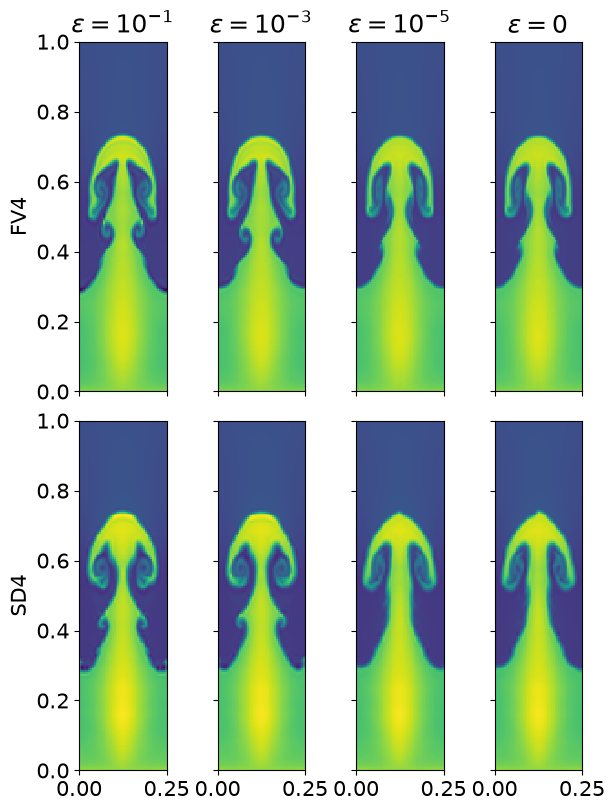

In [16]:
fig, axs = plt.subplots(2, 4, sharex=True, sharey=True, constrained_layout=True, figsize=(6, 8))
axs[0, 0].set_ylabel("FV4")
axs[1, 0].set_ylabel("SD4")
axs[0, 0].set_title(r"$\varepsilon=10^{-1}$")
axs[0, 1].set_title(r"$\varepsilon=10^{-3}$")
axs[0, 2].set_title(r"$\varepsilon=10^{-5}$")
axs[0, 3].set_title(r"$\varepsilon=0$")

meshes = []
for i, s in enumerate([s1, s2, s3, s4]):
    meshes.append(plot_fv(axs[0, i], s))
for i, s in enumerate([s5, s6, s7, s8]):
    meshes.append(plot_sd(axs[1, i], s))

vmin = min(m.get_array().min() for m in meshes)
vmax = max(m.get_array().max() for m in meshes)

for m in meshes:
    m.set_clim(vmin, vmax)